# Hoja de Ejercicios de Series de Tiempo

**Curso:** CC3084 - Data Science

**Nombre:** Dulce Ambrosio - 231143

In [28]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import os
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.tsa.holtwinters import ExponentialSmoothing, SimpleExpSmoothing
import warnings
warnings.filterwarnings("ignore")

# EJERCICIO 1

--- Extremos de temperatura por capa ---
temperature_2m_c: Mín 18.97°C, Máx 28.69°C
skin_temperature_c: Mín 19.15°C, Máx 29.74°C
soil_temperature_layer_1_c: Mín 19.84°C, Máx 30.29°C
soil_temperature_layer_2_c: Mín 19.96°C, Máx 29.80°C
soil_temperature_layer_3_c: Mín 20.49°C, Máx 28.35°C
soil_temperature_layer_4_c: Mín 21.57°C, Máx 26.88°C


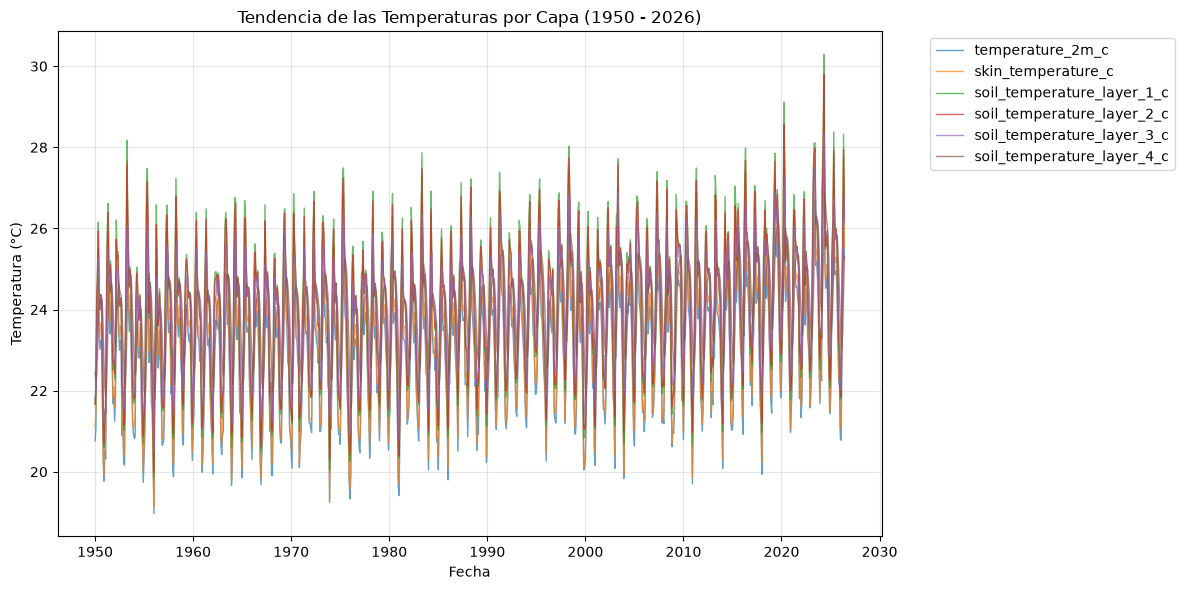

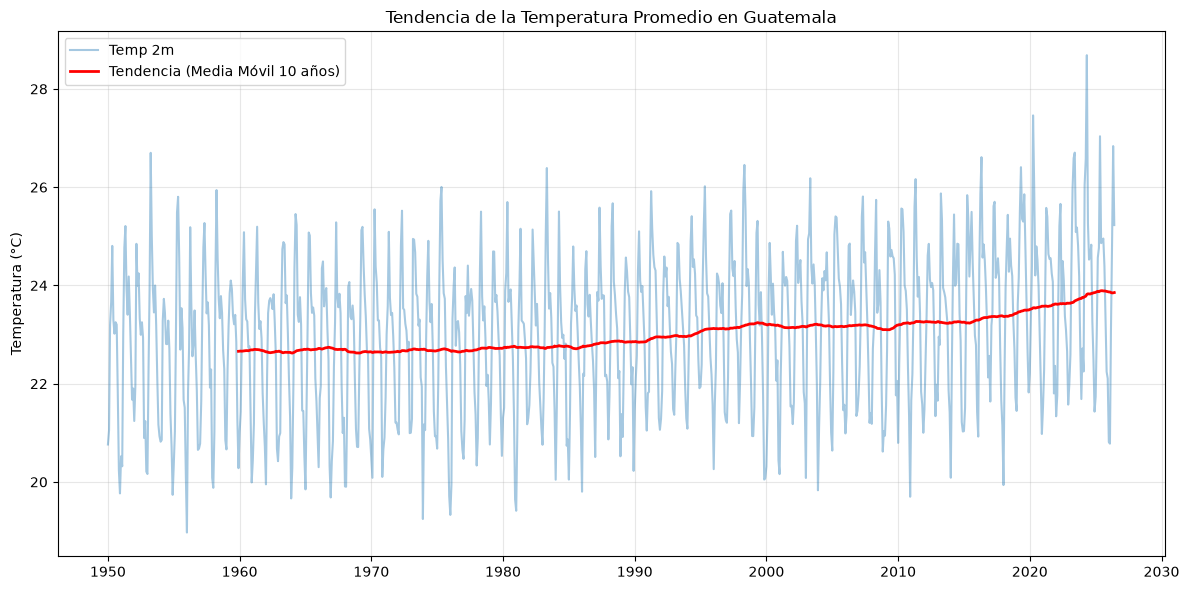

In [29]:
def explorar_datos(filepath):
    # Cargar los datos
    df = pd.read_csv(filepath)
    df['month'] = pd.to_datetime(df['month'])
    
    # Definir las columnas de temperatura por capa
    temp_columns = [
        'temperature_2m_c', 'skin_temperature_c', 
        'soil_temperature_layer_1_c', 'soil_temperature_layer_2_c', 
        'soil_temperature_layer_3_c', 'soil_temperature_layer_4_c'
    ]
    
    # Calcular extremos por capa
    print("--- Extremos de temperatura por capa ---")
    for col in temp_columns:
        print(f"{col}: Mín {df[col].min():.2f}°C, Máx {df[col].max():.2f}°C")
        
    # --- Gráfico 1: Tendencia de todas las capas ---
    plt.figure(figsize=(12, 6))
    for col in temp_columns:
        plt.plot(df['month'], df[col], label=col, alpha=0.7, linewidth=1)
        
    plt.title('Tendencia de las Temperaturas por Capa (1950 - 2026)')
    plt.xlabel('Fecha')
    plt.ylabel('Temperatura (°C)')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    # --- Gráfico 2: Tendencia general (Media Móvil a 10 años) ---
    df.set_index('month', inplace=True)
    media_movil_10a = df['temperature_2m_c'].rolling(window=120).mean() # 120 meses = 10 años
    
    plt.figure(figsize=(12, 6))
    plt.plot(df.index, df['temperature_2m_c'], label='Temp 2m', alpha=0.4)
    plt.plot(df.index, media_movil_10a, label='Tendencia (Media Móvil 10 años)', color='red', linewidth=2)
    plt.title('Tendencia de la Temperatura Promedio en Guatemala')
    plt.ylabel('Temperatura (°C)')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    explorar_datos('../data/guatemala_temperatura.csv')

# Ejercicio 2

In [30]:
def preparar_y_dividir_datos(input_filepath, output_dir="../data/processed"):
    # 1. Cargar los datos crudos
    df = pd.read_csv(input_filepath)
    
    # 2. Formatear la fecha y establecerla como índice
    df['month'] = pd.to_datetime(df['month'])
    df.set_index('month', inplace=True)
    
    # 3. Ordenar cronológicamente (buena práctica en Series de Tiempo)
    df.sort_index(inplace=True)
    
    # 4. Dividir en Entrenamiento y Prueba (últimos 36 meses)
    test_size = 36
    train_df = df.iloc[:-test_size]
    test_df = df.iloc[-test_size:]
    
    print(f"Entrenamiento: {len(train_df)} meses | Desde {train_df.index.min().date()} hasta {train_df.index.max().date()}")
    print(f"Prueba: {len(test_df)} meses | Desde {test_df.index.min().date()} hasta {test_df.index.max().date()}")
    
    # 5. Guardar los datos procesados para los siguientes ejercicios
    os.makedirs(output_dir, exist_ok=True)
    train_df.to_csv(os.path.join(output_dir, 'train.csv'))
    test_df.to_csv(os.path.join(output_dir, 'test.csv'))
    print("Archivos 'train.csv' y 'test.csv' guardados con éxito en la carpeta processed/.")

if __name__ == "__main__":
    preparar_y_dividir_datos(
        input_filepath='../data/guatemala_temperatura.csv',
        output_dir='../data/processed'
    )

Entrenamiento: 882 meses | Desde 1950-01-01 hasta 2023-06-01
Prueba: 36 meses | Desde 2023-07-01 hasta 2026-06-01
Archivos 'train.csv' y 'test.csv' guardados con éxito en la carpeta processed/.


# Ejercicio 3


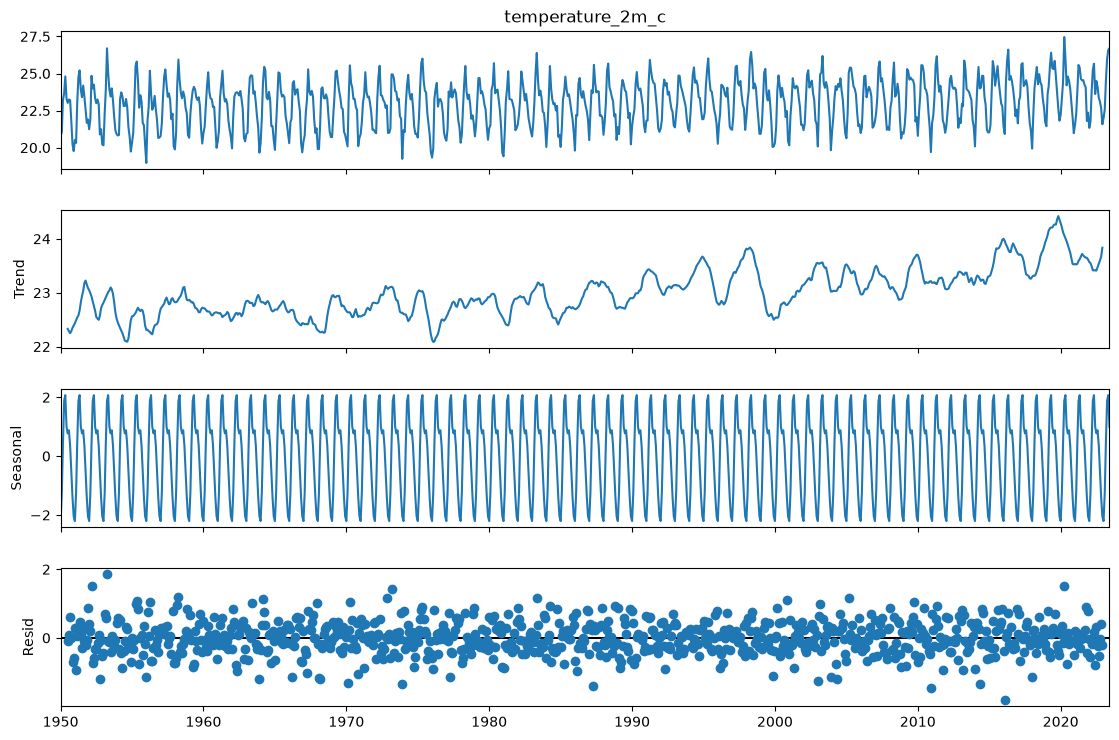

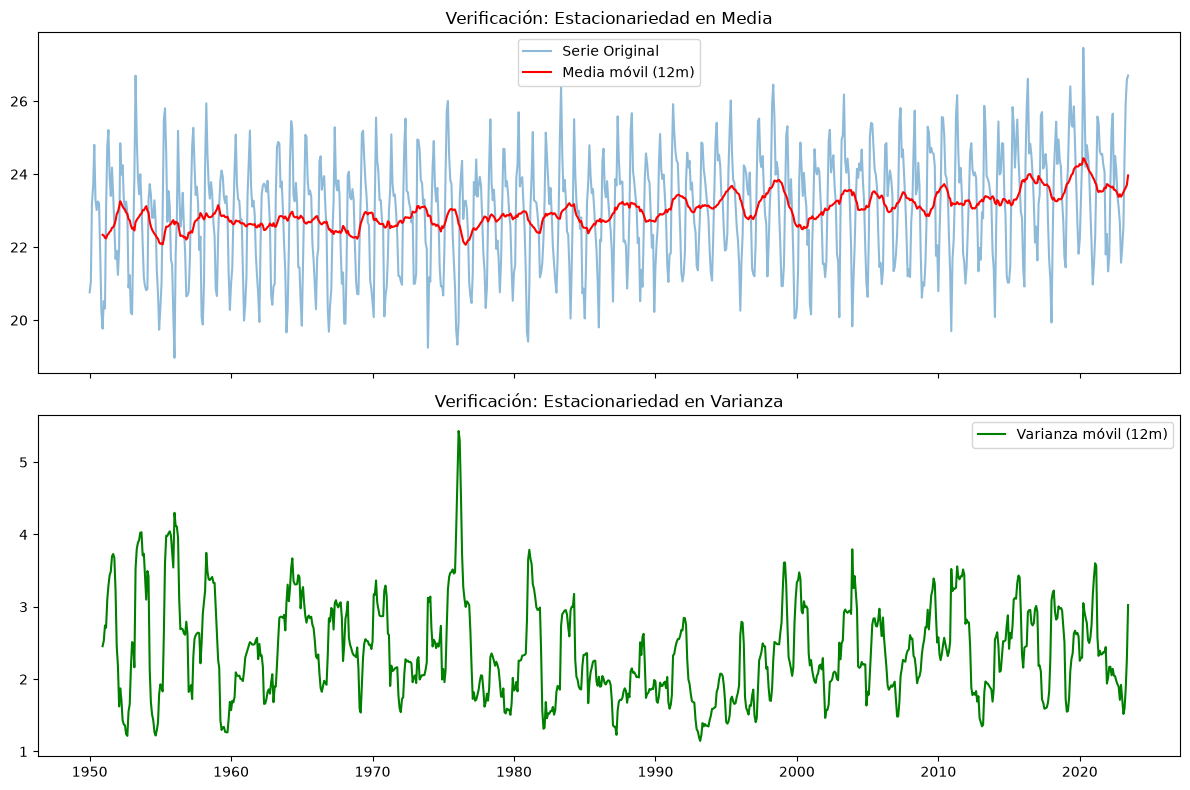

ADF p-valor: 0.00035
KPSS p-valor: 0.01000


In [31]:
def analizar_serie(train_filepath):
    # Cargar conjunto de entrenamiento
    train_df = pd.read_csv(train_filepath)
    train_df['month'] = pd.to_datetime(train_df['month'])
    train_df.set_index('month', inplace=True)
    
    # Extraer la serie específica
    serie = train_df['temperature_2m_c']
    # Inferir frecuencia mensual
    serie.index.freq = pd.infer_freq(serie.index)

    # 1. Descomposición Aditiva
    decomposition = seasonal_decompose(serie, model='additive')
    fig = decomposition.plot()
    fig.set_size_inches(12, 8)
    plt.show()

    # 2. Media y Varianza Móvil (Ventana 12 meses)
    ventana = 12
    media_movil = serie.rolling(ventana).mean()
    var_movil = serie.rolling(ventana).var()

    fig, ax = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
    ax[0].plot(serie, label="Serie Original", alpha=0.5)
    ax[0].plot(media_movil, label=f"Media móvil ({ventana}m)", color="red")
    ax[0].set_title("Verificación: Estacionariedad en Media")
    ax[0].legend()

    ax[1].plot(var_movil, label=f"Varianza móvil ({ventana}m)", color="green")
    ax[1].set_title("Verificación: Estacionariedad en Varianza")
    ax[1].legend()
    plt.tight_layout()
    plt.show()

    # 3. Pruebas estadísticas
    adf_result = adfuller(serie)
    print(f"ADF p-valor: {adf_result[1]:.5f}")

    kpss_result = kpss(serie, regression='c', nlags="auto")
    print(f"KPSS p-valor: {kpss_result[1]:.5f}")

if __name__ == "__main__":
    analizar_serie('../data/processed/train.csv')

# Ejercicio 4

ADF p-valor (Serie Diferenciada 1, 12): 9.0506558548e-26


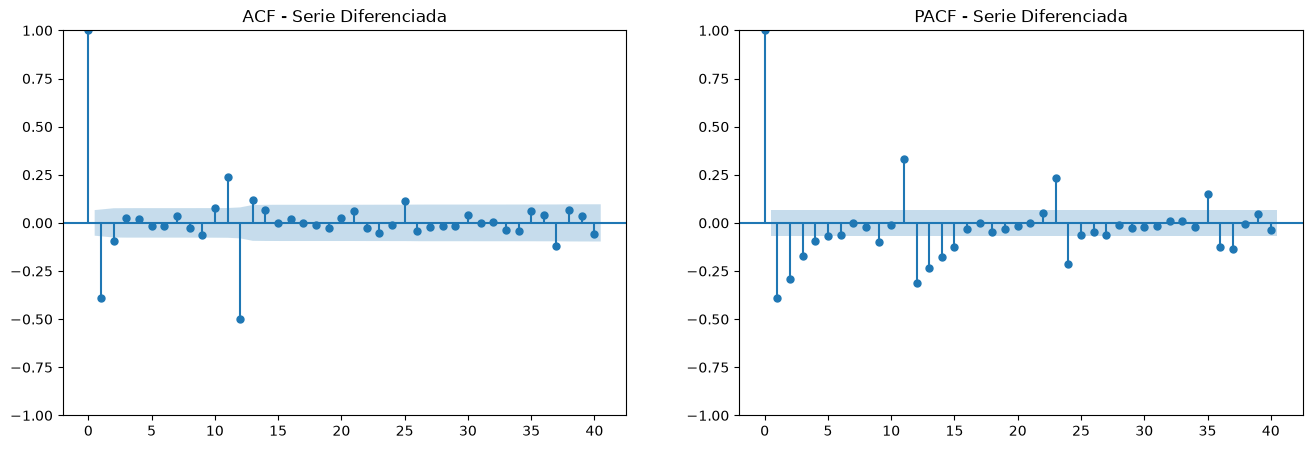


--- Entrenando Modelos ---
Modelo 1 -> SARIMA(1,1,1)x(0,1,1,12) | AIC: 1436.73
Modelo 2 -> ARIMA(2,1,2)             | AIC: 2175.16
Modelo 3 -> SARIMA(2,1,2)x(1,1,1,12) | AIC: 1413.11


In [32]:
def entrenar_modelos_arima(train_filepath):
    # 1. Cargar datos
    train_df = pd.read_csv(train_filepath)
    train_df['month'] = pd.to_datetime(train_df['month'])
    train_df.set_index('month', inplace=True)
    serie = train_df['temperature_2m_c']
    serie.index.freq = pd.infer_freq(serie.index)

    # 2. Transformaciones (Diferenciación Estacional + Regular)
    serie_diff12 = serie.diff(12).dropna()      # Estacional (s=12)
    serie_diff_1_12 = serie_diff12.diff(1).dropna() # Regular (d=1)

    # Verificar Estacionariedad
    adf_result = adfuller(serie_diff_1_12)
    print(f"ADF p-valor (Serie Diferenciada 1, 12): {adf_result[1]:.10e}")

    # 3. Gráficos ACF y PACF
    fig, ax = plt.subplots(1, 2, figsize=(16, 5))
    plot_acf(serie_diff_1_12, lags=40, ax=ax[0], title='ACF - Serie Diferenciada')
    plot_pacf(serie_diff_1_12, lags=40, ax=ax[1], title='PACF - Serie Diferenciada')
    plt.show()

    # 4. Entrenamiento de Modelos
    print("\n--- Entrenando Modelos ---")
    
    # Modelo 1: Estimación Visual SARIMA
    mod1 = SARIMAX(serie, order=(1, 1, 1), seasonal_order=(0, 1, 1, 12), 
                   enforce_stationarity=False, enforce_invertibility=False)
    res1 = mod1.fit(disp=False)
    print(f"Modelo 1 -> SARIMA(1,1,1)x(0,1,1,12) | AIC: {res1.aic:.2f}")

    # Modelo 2: ARIMA sin estacionalidad
    mod2 = SARIMAX(serie, order=(2, 1, 2), 
                   enforce_stationarity=False, enforce_invertibility=False)
    res2 = mod2.fit(disp=False)
    print(f"Modelo 2 -> ARIMA(2,1,2)             | AIC: {res2.aic:.2f}")

    # Modelo 3: SARIMA más complejo (Nuestro Mejor Modelo)
    mod3 = SARIMAX(serie, order=(2, 1, 2), seasonal_order=(1, 1, 1, 12), 
                   enforce_stationarity=False, enforce_invertibility=False)
    res3 = mod3.fit(disp=False)
    print(f"Modelo 3 -> SARIMA(2,1,2)x(1,1,1,12) | AIC: {res3.aic:.2f}")
    
    return res3 # Retornamos el mejor modelo para el Ejercicio 5

if __name__ == "__main__":
    mejor_modelo = entrenar_modelos_arima('../data/processed/train.csv')

# Ejercicio 5

                                      SARIMAX Results                                       
Dep. Variable:                     temperature_2m_c   No. Observations:                  882
Model:             SARIMAX(2, 1, 2)x(1, 1, [1], 12)   Log Likelihood                -699.555
Date:                              Fri, 17 Jul 2026   AIC                           1413.111
Time:                                      01:40:37   BIC                           1446.360
Sample:                                  01-01-1950   HQIC                          1425.844
                                       - 06-01-2023                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.8067      0.152      5.311      0.000       0.509       1.104
ar.L2         -0.02

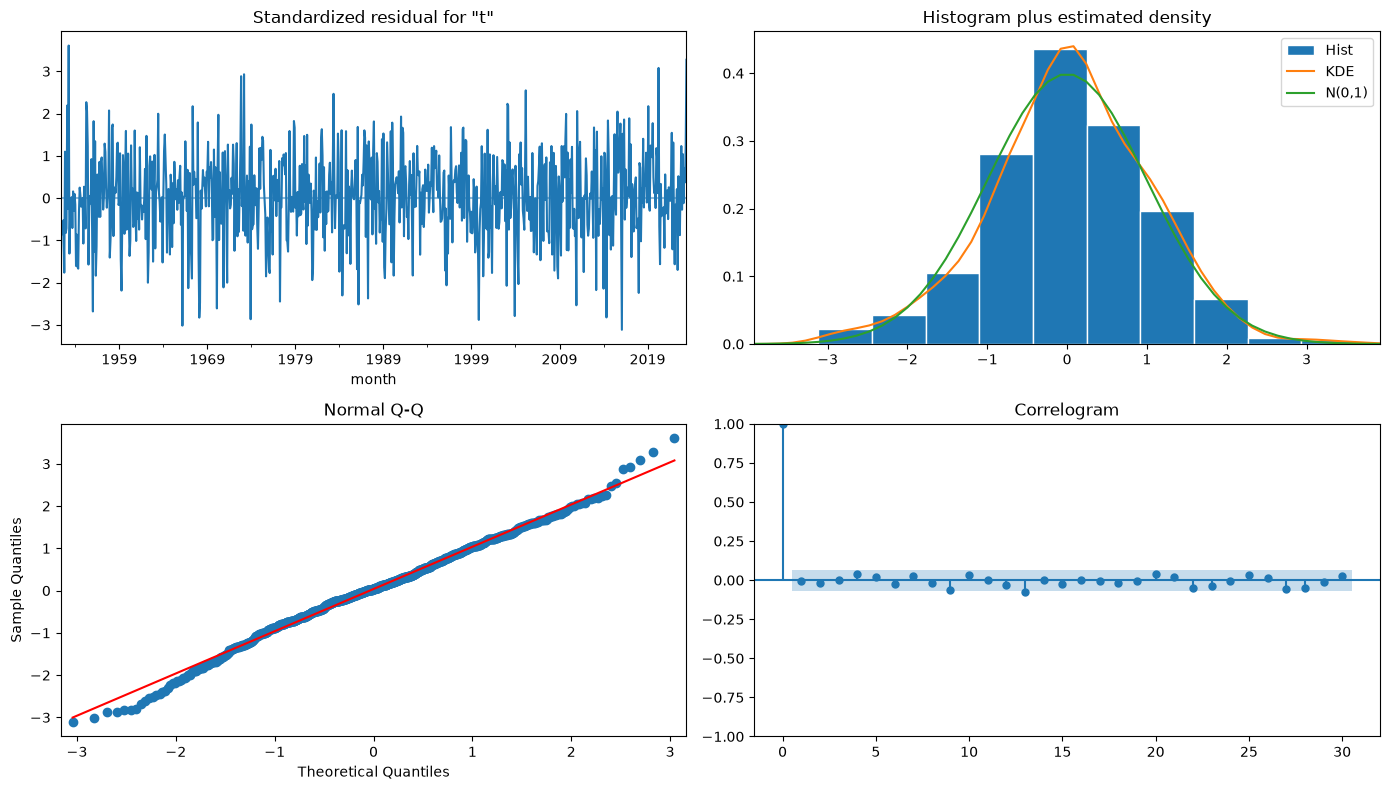


Resultados Ljung-Box Test (p-valores > 0.05 indican ruido blanco):
       lb_stat     lb_pvalue
10   46.176517  1.332393e-06
20  148.547940  1.191796e-21
30  159.836250  1.177380e-19


In [33]:
def validar_modelo(train_filepath):
    # Cargar datos
    train_df = pd.read_csv(train_filepath)
    train_df['month'] = pd.to_datetime(train_df['month'])
    train_df.set_index('month', inplace=True)
    serie = train_df['temperature_2m_c']
    serie.index.freq = pd.infer_freq(serie.index)

    # Entrenar el modelo seleccionado
    modelo = SARIMAX(serie, order=(2, 1, 2), seasonal_order=(1, 1, 1, 12), 
                   enforce_stationarity=False, enforce_invertibility=False)
    resultados = modelo.fit(disp=False)

    # a) y c) Imprimir Resumen del modelo (Coeficientes, AIC, BIC)
    print(resultados.summary())

    # b) Diagnóstico de Residuales
    # Generar gráficos de residuos
    fig = plt.figure(figsize=(14, 8))
    fig = resultados.plot_diagnostics(fig=fig, lags=30)
    plt.tight_layout()
    plt.show()

    # Prueba de Ljung-Box
    ljung_box = acorr_ljungbox(resultados.resid, lags=[10, 20, 30], return_df=True)
    print("\nResultados Ljung-Box Test (p-valores > 0.05 indican ruido blanco):")
    print(ljung_box)
    
    return resultados

if __name__ == "__main__":
    modelo_validado = validar_modelo('../data/processed/train.csv')

# Ejercicio 6

Entrenando modelo SARIMA...
Métricas de Evaluación en Prueba (Test):
RMSE: 0.8368 °C
MAE:  0.5814 °C


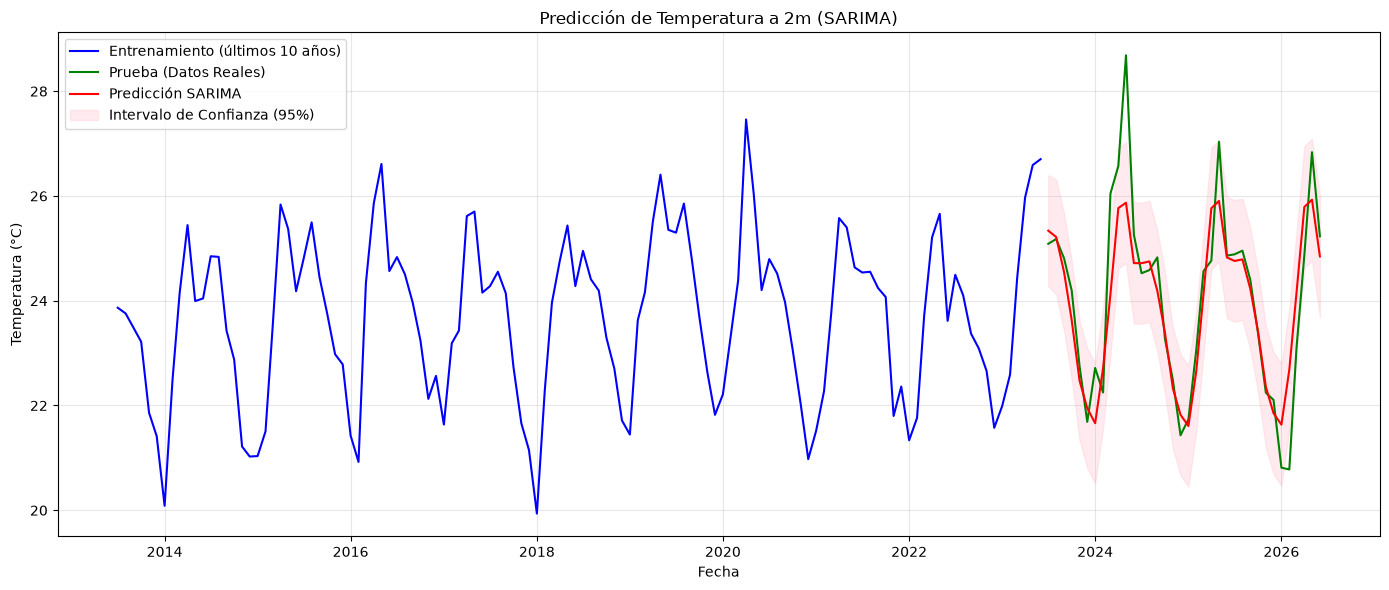

In [34]:
def predecir_y_evaluar(input_filepath):
    # 1. Cargar la serie completa y dividir
    df = pd.read_csv(input_filepath)
    df['month'] = pd.to_datetime(df['month'])
    df.set_index('month', inplace=True)
    serie = df['temperature_2m_c']
    serie.index.freq = pd.infer_freq(serie.index)

    test_size = 36
    train = serie.iloc[:-test_size]
    test = serie.iloc[-test_size:]

    # 2. Entrenar el mejor modelo
    print("Entrenando modelo SARIMA...")
    modelo = SARIMAX(train, order=(2, 1, 2), seasonal_order=(1, 1, 1, 12), 
                     enforce_stationarity=False, enforce_invertibility=False)
    resultado = modelo.fit(disp=False)

    # 3. Hacer predicciones (36 pasos)
    predicciones = resultado.get_forecast(steps=test_size)
    pred_mean = predicciones.predicted_mean
    pred_ci = predicciones.conf_int()

    # 4. Calcular métricas de error
    rmse = np.sqrt(mean_squared_error(test, pred_mean))
    mae = mean_absolute_error(test, pred_mean)
    print(f"Métricas de Evaluación en Prueba (Test):")
    print(f"RMSE: {rmse:.4f} °C")
    print(f"MAE:  {mae:.4f} °C")

    # 5. Visualizar resultados (últimos años)
    plt.figure(figsize=(14, 6))
    plt.plot(train.index[-120:], train.iloc[-120:], label='Entrenamiento (últimos 10 años)', color='blue')
    plt.plot(test.index, test, label='Prueba (Datos Reales)', color='green')
    plt.plot(pred_mean.index, pred_mean, label='Predicción SARIMA', color='red')
    plt.fill_between(pred_ci.index, pred_ci.iloc[:, 0], pred_ci.iloc[:, 1], color='pink', alpha=0.3, label='Intervalo de Confianza (95%)')
    
    plt.title('Predicción de Temperatura a 2m (SARIMA)')
    plt.xlabel('Fecha')
    plt.ylabel('Temperatura (°C)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    predecir_y_evaluar('../data/guatemala_temperatura.csv')

# Ejercicio 7

--- Evaluación de Otros Modelos ---
Holt-Winters - RMSE: 0.9443, MAE: 0.7305
Seasonal Naive - RMSE: 0.9872, MAE: 0.7973
Suavizamiento Exponencial Simple - RMSE: 3.2050, MAE: 2.7844


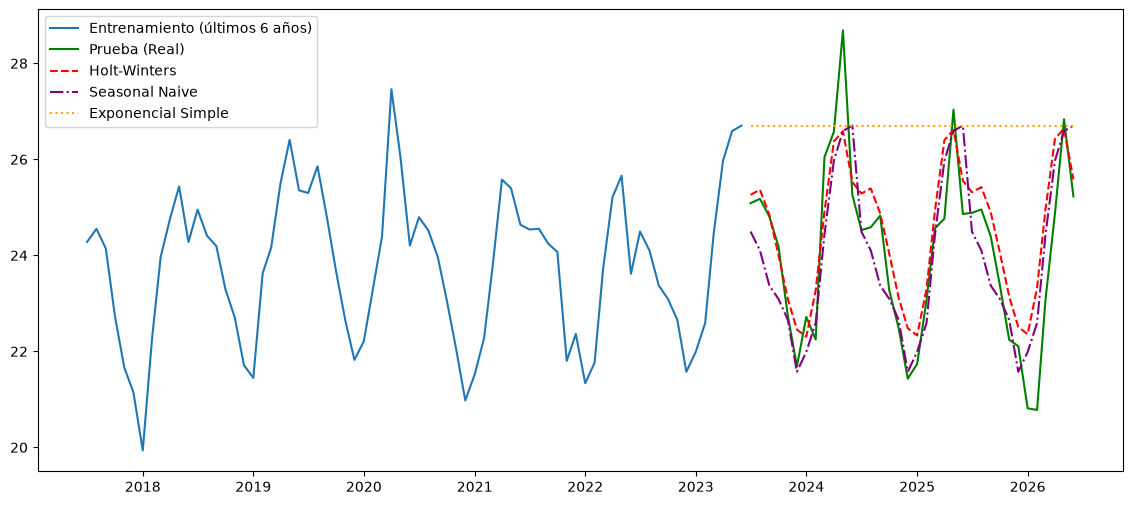

In [35]:
def evaluar_modelos(input_filepath):
    # Preparar datos
    df = pd.read_csv(input_filepath)
    df['month'] = pd.to_datetime(df['month'])
    df.set_index('month', inplace=True)
    df.sort_index(inplace=True)
    
    serie = df['temperature_2m_c']
    serie.index.freq = pd.infer_freq(serie.index)

    test_size = 36
    train = serie.iloc[:-test_size]
    test = serie.iloc[-test_size:]

    # 1. Holt-Winters
    hw_model = ExponentialSmoothing(train, trend='add', seasonal='add', seasonal_periods=12)
    hw_pred = hw_model.fit().forecast(test_size)

    # 2. Suavizamiento Exponencial Simple
    ses_pred = SimpleExpSmoothing(train).fit().forecast(test_size)

    # 3. Seasonal Naive
    snaive_pred = pd.Series(np.tile(train.iloc[-12:], 3), index=test.index)

    # Evaluación
    def print_metrics(y_true, y_pred, nombre):
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        mae = mean_absolute_error(y_true, y_pred)
        print(f"{nombre} - RMSE: {rmse:.4f}, MAE: {mae:.4f}")

    print("--- Evaluación de Otros Modelos ---")
    print_metrics(test, hw_pred, "Holt-Winters")
    print_metrics(test, snaive_pred, "Seasonal Naive")
    print_metrics(test, ses_pred, "Suavizamiento Exponencial Simple")

    # Gráfica
    plt.figure(figsize=(14, 6))
    plt.plot(train.index[-72:], train.iloc[-72:], label='Entrenamiento (últimos 6 años)')
    plt.plot(test.index, test, label='Prueba (Real)', color='green')
    plt.plot(test.index, hw_pred, label='Holt-Winters', color='red', linestyle='--')
    plt.plot(test.index, snaive_pred, label='Seasonal Naive', color='purple', linestyle='-.')
    plt.plot(test.index, ses_pred, label='Exponencial Simple', color='orange', linestyle=':')
    plt.legend()
    plt.show()

if __name__ == "__main__":
    evaluar_modelos('../data/guatemala_temperatura.csv')

# Ejercicio 8

Entrenando el modelo SARIMA con todos los datos...

--- Predicciones Valores Actuales/Futuros ---
2026-07-01    24.802136
2026-08-01    24.855387
2026-09-01    24.324920
2026-10-01    23.474061
2026-11-01    22.443771
2026-12-01    21.868889
Freq: MS, Name: predicted_mean, dtype: float64


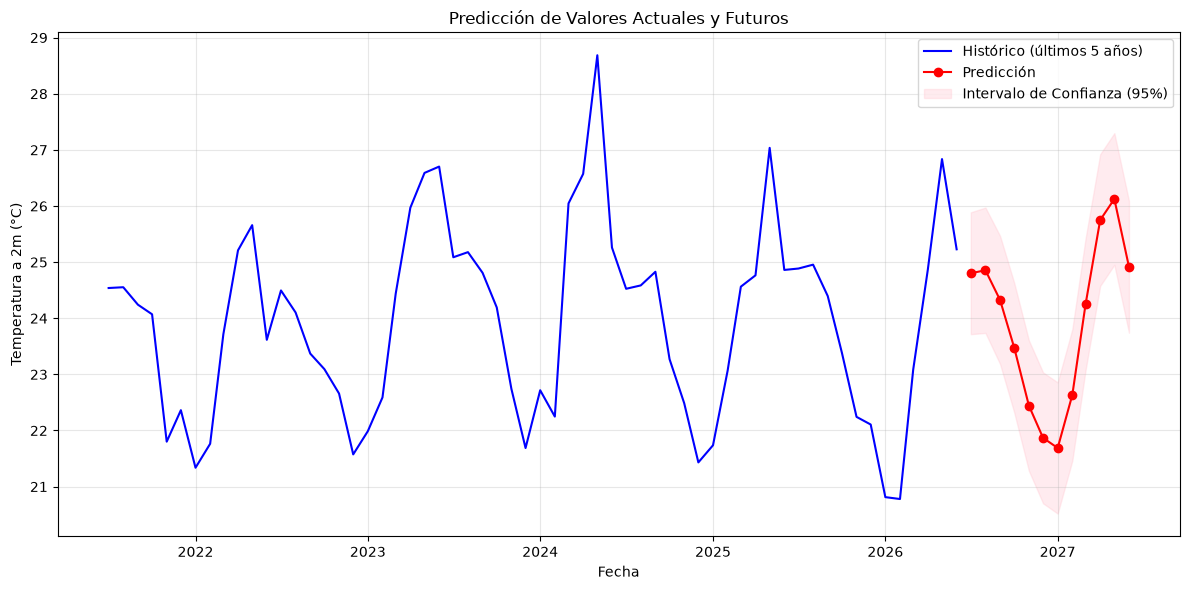

In [36]:
def predecir_actualidad(input_filepath):
    # Cargar todos los datos disponibles
    df = pd.read_csv(input_filepath)
    df['month'] = pd.to_datetime(df['month'])
    df.set_index('month', inplace=True)
    df.sort_index(inplace=True)
    
    # Tomar la serie completa
    serie = df['temperature_2m_c']
    serie.index.freq = pd.infer_freq(serie.index)

    # Entrenar el modelo con todo el dataset
    print("Entrenando el modelo SARIMA con todos los datos...")
    modelo_final = SARIMAX(serie, order=(2, 1, 2), seasonal_order=(1, 1, 1, 12), 
                     enforce_stationarity=False, enforce_invertibility=False)
    resultado_final = modelo_final.fit(disp=False)

    # Predecir los próximos 12 meses (incluyendo la fecha actual)
    pasos_futuros = 12
    prediccion_actual = resultado_final.get_forecast(steps=pasos_futuros)
    pred_mean = prediccion_actual.predicted_mean
    pred_ci = prediccion_actual.conf_int()

    print("\n--- Predicciones Valores Actuales/Futuros ---")
    print(pred_mean.head(6))

    # Generar Visualización
    plt.figure(figsize=(12, 6))
    plt.plot(serie.index[-60:], serie.iloc[-60:], label='Histórico (últimos 5 años)', color='blue')
    plt.plot(pred_mean.index, pred_mean, label='Predicción', color='red', marker='o')
    plt.fill_between(pred_ci.index, pred_ci.iloc[:, 0], pred_ci.iloc[:, 1], color='pink', alpha=0.3, label='Intervalo de Confianza (95%)')

    plt.title('Predicción de Valores Actuales y Futuros')
    plt.xlabel('Fecha')
    plt.ylabel('Temperatura a 2m (°C)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    predecir_actualidad('../data/guatemala_temperatura.csv')